In [3]:
# =========================
# IMPORTS
# =========================
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from matplotlib import colors
import matplotlib.patches as mpatches



# =========================
# LOAD SINGLE SEED RESULT
# =========================
def load_results(path):
    with open(path, 'rb') as file:
        linkabilityresults = pickle.load(file)
    
    tools = ['Avatars K5', "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
    columns = [2,3,5,7,10,20,50]
    ResultasDataset = {}
    for tool, result_as_tool in linkabilityresults.items():
        tool_res = {}
        for i, evaluator in enumerate(result_as_tool):
            # name_feature = feature[0]
            # evaluator = feature[1]
    
            attack_risk = evaluator.risk().value
            naive_risk = evaluator.risk(baseline=True).value
    
            if attack_risk <= naive_risk:
                final_risk = np.nan
            else:
                final_risk = attack_risk
            tool_res[columns[i]] = final_risk
    
        ResultasDataset[tool] = tool_res
        
    df = pd.DataFrame(ResultasDataset).T
    df.index = tools
    df.columns = columns
    return df


# =========================
# AGGREGATE MULTIPLE SEEDS
# =========================
def aggregate_seeds(dfs, method="mean"):
    stacked = np.stack([df.values for df in dfs], axis=0)

    if method == "mean":
        agg = np.nanmean(stacked, axis=0)
    elif method == "median":
        agg = np.nanmedian(stacked, axis=0)
    else:
        raise ValueError("method must be 'mean' or 'median'")

    return pd.DataFrame(
        agg,
        index=dfs[0].index,
        columns=dfs[0].columns
    )


def collect_boxplot_data(dfs):
    """
    Collect all linkability risk values across
    ratios (25/50/75/100) and seeds for each tool.
    """
    box_data = {}
    tools = dfs[0].index

    for tool in tools:
        values = []
        for df in dfs:
            vals = df.loc[tool].values
            vals = vals[~np.isnan(vals)]
            values.extend(vals)
        box_data[tool] = np.array(values)

    return box_data

def _overlay_hatched_missing_cells(
    ax: plt.Axes,
    mat: pd.DataFrame,
    hatch: str = "///",
    edgecolor: str = "#BDBDBD",
    facecolor: str = "#FFFFFF",
    linewidth: float = 0.6,
) -> None:
    nrows, ncols = mat.shape
    nan_mask = mat.isna().to_numpy()

    for i in range(nrows):
        for j in range(ncols):
            if not nan_mask[i, j]:
                continue
            rect = mpatches.Rectangle(
                (j, i),
                1.0,
                1.0,
                facecolor=facecolor,
                edgecolor=edgecolor,
                hatch=hatch,
                linewidth=linewidth,
                fill=True,
                zorder=10,
            )
            ax.add_patch(rect)

In [4]:
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
seeds = [0, 1, 2, 3, 42]

ResultsSO_Uni = {cancer: [] for cancer in cancers}

for cancer in cancers:
    for seed in seeds:
        path = f'../{cancer}/Privacy/SinglingOut/MultiSO/Seed_{seed}/MultiSO_Results.pkl'
        df = load_results(path)
        ResultsSO_Uni[cancer].append(df)

# Aggregate (mean heatmap)
ResultsSO_UniAgg = {
    cancer: aggregate_seeds(dfs, method="mean")
    for cancer, dfs in ResultsSO_Uni.items()
}

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0002919607855012302, baseline = 0.0004918839858270949. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.00019199918533829787, baseline = 0.00019199918533829787. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.014886354409289352, baseline = 0.017585317613688527. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/conf

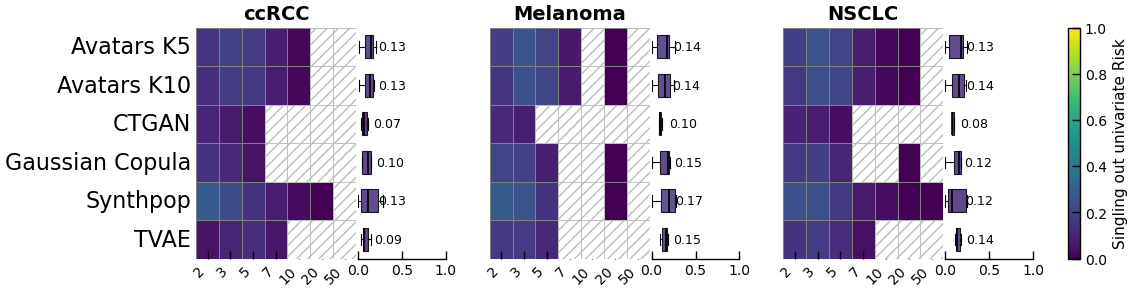

In [11]:
# =========================
# STYLE CONFIG
# =========================
plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False
})

vmin, vmax = 0, 1
cmap = plt.get_cmap("viridis")
norm = colors.Normalize(vmin=vmin, vmax=vmax)

line_params = {
    'linewidths': 0.5,
    'linecolor': 'gray'
}

# =========================
# FIGURE LAYOUT (9 COLUMNS)
# =========================
fig, axes = plt.subplots(
    1, 9,
    figsize=(12, 3),
    gridspec_kw={
        'width_ratios': [1, 0.55, 0.25,
                         1, 0.55, 0.25,
                         1, 0.55, 0.25],
        'wspace': 0.02
    }
)

steps = [0, 3, 6]

# =========================
# PLOTTING
# =========================
for idx, step in enumerate(steps):

    dataset = cancers[idx]
    ax_heat = axes[step]
    ax_box  = axes[step + 1]

    # spacer
    axes[step + 2].axis('off')

    data_mean = ResultsSO_UniAgg[dataset]
    data_all  = ResultsSO_Uni[dataset]

    yticklabels = True if idx == 0 else False

    # ---- HEATMAP ----
    sns.heatmap(
        data_mean,
        ax=ax_heat,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=True,
        yticklabels=yticklabels,
        **line_params
    )

    _overlay_hatched_missing_cells(
        ax=ax_heat,
        mat=data_mean,
        hatch="///"
    )

    ax_heat.set_title(dataset, fontsize=14, fontweight='bold')
    ax_heat.tick_params(left=False, right=False)

    for label in ax_heat.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        label.set_fontsize(10)

    # ---- BOXPLOT (HORIZONTAL) ----
    boxplot_data = collect_boxplot_data(data_all)
    tools = data_mean.index.tolist()

    y_pos = np.arange(len(tools)) + 0.5
    box_values = [boxplot_data[t] for t in tools]

    bp = ax_box.boxplot(
        box_values,
        vert=False,
        positions=y_pos,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(linewidth=0.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8)
    )


    # ---- color boxes using mean risk ----
    means = data_mean.mean(axis=1).values
    for patch, m in zip(bp['boxes'], means):
        patch.set_facecolor(cmap(norm(m)))
        patch.set_alpha(0.85)

    # ---- annotate mean values ----
    for i, tool in enumerate(tools):
        vals = boxplot_data[tool]
        y = y_pos[i]

        if len(vals) == 0:
            ax_box.text(
                0.01, y,
                "NA",
                va="center",
                ha="left",
                fontsize=9,
                color="black",
                zorder=10
            )
        else:
            x_offset = 0.1
            mean_val = np.mean(vals)
            ax_box.text(
                mean_val + x_offset,
                y,
                f"{mean_val:.2f}",
                va="center",
                ha="left",
                fontsize=9,
                color="black",
                zorder=10
            )

    # ---- align & clean axis ----
    ax_box.set_ylim(ax_heat.get_ylim())
    ax_box.set_xlim(vmin, vmax)
    ax_box.set_yticks([])
    ax_box.spines['left'].set_visible(False)
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)
    ax_box.tick_params(axis='x', labelsize=10)
    ax_box.tick_params(which='both', left=False)

# ---- remove top ticks for all axes ----
for ax in axes:
    ax.tick_params(top=False, labeltop=False)

# =========================
# SHARED COLORBAR
# =========================
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

valid_axes = [axes[0], axes[1],
              axes[3], axes[4],
              axes[6], axes[7]]

cbar = fig.colorbar(
    sm,
    ax=valid_axes,
    fraction=0.015,
    pad=0.04
)

cbar.set_label("Singling out univariate Risk", fontsize=11)
cbar.ax.tick_params(labelsize=10)

# =========================
# SHOW / SAVE
# =========================
plt.show()
fig.savefig("AggreFig/SO_Multi_Heatmap_Boxplot.pdf", dpi=300, bbox_inches="tight")